# Weak-lensing galaxy shape catalogue validation 1

## Global metacalibration

Call from master notebook, after steps 1-4 have been carried out by call
of `set_up_data_match_select.ipybn`.

Contents.

5. Metacalibration (global)

The selection criteria for galaxies are
- Flags = 0 to select valid objects
- $\frac{T_{\rm gal}}{T_{\rm psf}}$ > 0.5  to select objects that are not too small compared to the PSF, thus not likely to be point-like
- SNR > 10 to cut noisy objects
- SNR < 500 to cut too bright objects, potentially too large for the postage stamp

In [1]:
import os

In [22]:
from sp_validation.survey import *
from sp_validation.util import *
from sp_validation.basic import *
from sp_validation.plots import *

sp_base = '{}/astro/repositories/github/sp_validation'.format(os.environ['HOME'])

# The following commands will be replaced by import instructions, once the sp_validation scripts are stable
for sc in ['survey', 'io', 'cat', 'basic', 'util', 'plot_style', 'plots']:
    script = os.path.join(sp_base, 'sp_validation', sc)
    %run $script

In [3]:
# Load parameters
%run params.py

Field name = W3


In [4]:
nb_path = "{}/notebooks/validation_main.ipynb".format(sp_base)
execute_notebook(nb_path)

# Weak-lensing galaxy shape catalogue validation

## Main notebook.

Version 10/05/2021

Includes
- PSF residuals
- PSF to galaxy shapes leakage
- Additive shear bias
- Convergence E- and B-modes
- Cluster lensing

################################################################################

################################################################################

################################################################################
# Weak-lensing galaxy shape catalogue validation 1
Call from master notebook.

Contents
1. Set-up
2. Load data
3. Matching of stars
4. Select galaxies

################################################################################

################################################################################

################################################################################

## 2. Load data

### Load merged (final) galaxy catalogue

################################################################################

#

## Run metacalibration

### ngmix

In [5]:
gal_metacal_ngmix = metacal(dd, m_gal_ngmix)

Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


#### Get quantities for plots

In [7]:
# mask for 'no shear' images
mask_ns = gal_metacal_ngmix.mask_dict['ns']

# uncalibrated shear estimates
g_ngmix = np.array([gal_metacal_ngmix.ns['g1'][mask_ns], gal_metacal_ngmix.ns['g2'][mask_ns]])

# calibratied shear estimates: multiply with inverse response matrix
g_corr_ngmix = np.linalg.inv(gal_metacal_ngmix.R).dot(g_ngmix)

# weights
w_ngmix = gal_metacal_ngmix.ns['w'][mask_ns]

# The following quantities stem from the original tiles object catalogue, and thus the galaxy mask `m_gal_ngmix`
# needs to be applied.

# coordinates
ra_ngmix = dd['XWIN_WORLD'][m_gal_ngmix][mask_ns]
dec_ngmix = dd['YWIN_WORLD'][m_gal_ngmix][mask_ns]

# magnitude, from SExtractor
mag_ngmix = dd['MAG_AUTO'][m_gal_ngmix][mask_ns]

# signal-to-noise ratio, from ngmix fitted flux and error
snr_ngmix = dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix][mask_ns]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix][mask_ns]

In [8]:
# Galaxy number density

n_gal_ngmix = len(g_ngmix[0])

print_stats('ngmix:', stats_file, verbose=verbose)
print_stats('Number of galaxies = {}'.format(n_gal_ngmix), stats_file, verbose=verbose)
print_stats('Galaxy density = {:.2f} gal/arcmin2'.format(n_gal_ngmix / area_amin2), stats_file, verbose=verbose)

ngmix after metacalibration:
Number of galaxies = 9006
Galaxy density = 10.01 gal/arcmin2


#### Plot spatial distribution of objects

In [9]:
x_label = 'R.A. [deg]'
y_label = 'DEC [deg]'
cbar_label_base = 'Density [$A_{\\rm pix}^{-1}$]'

Number of pixels = 30


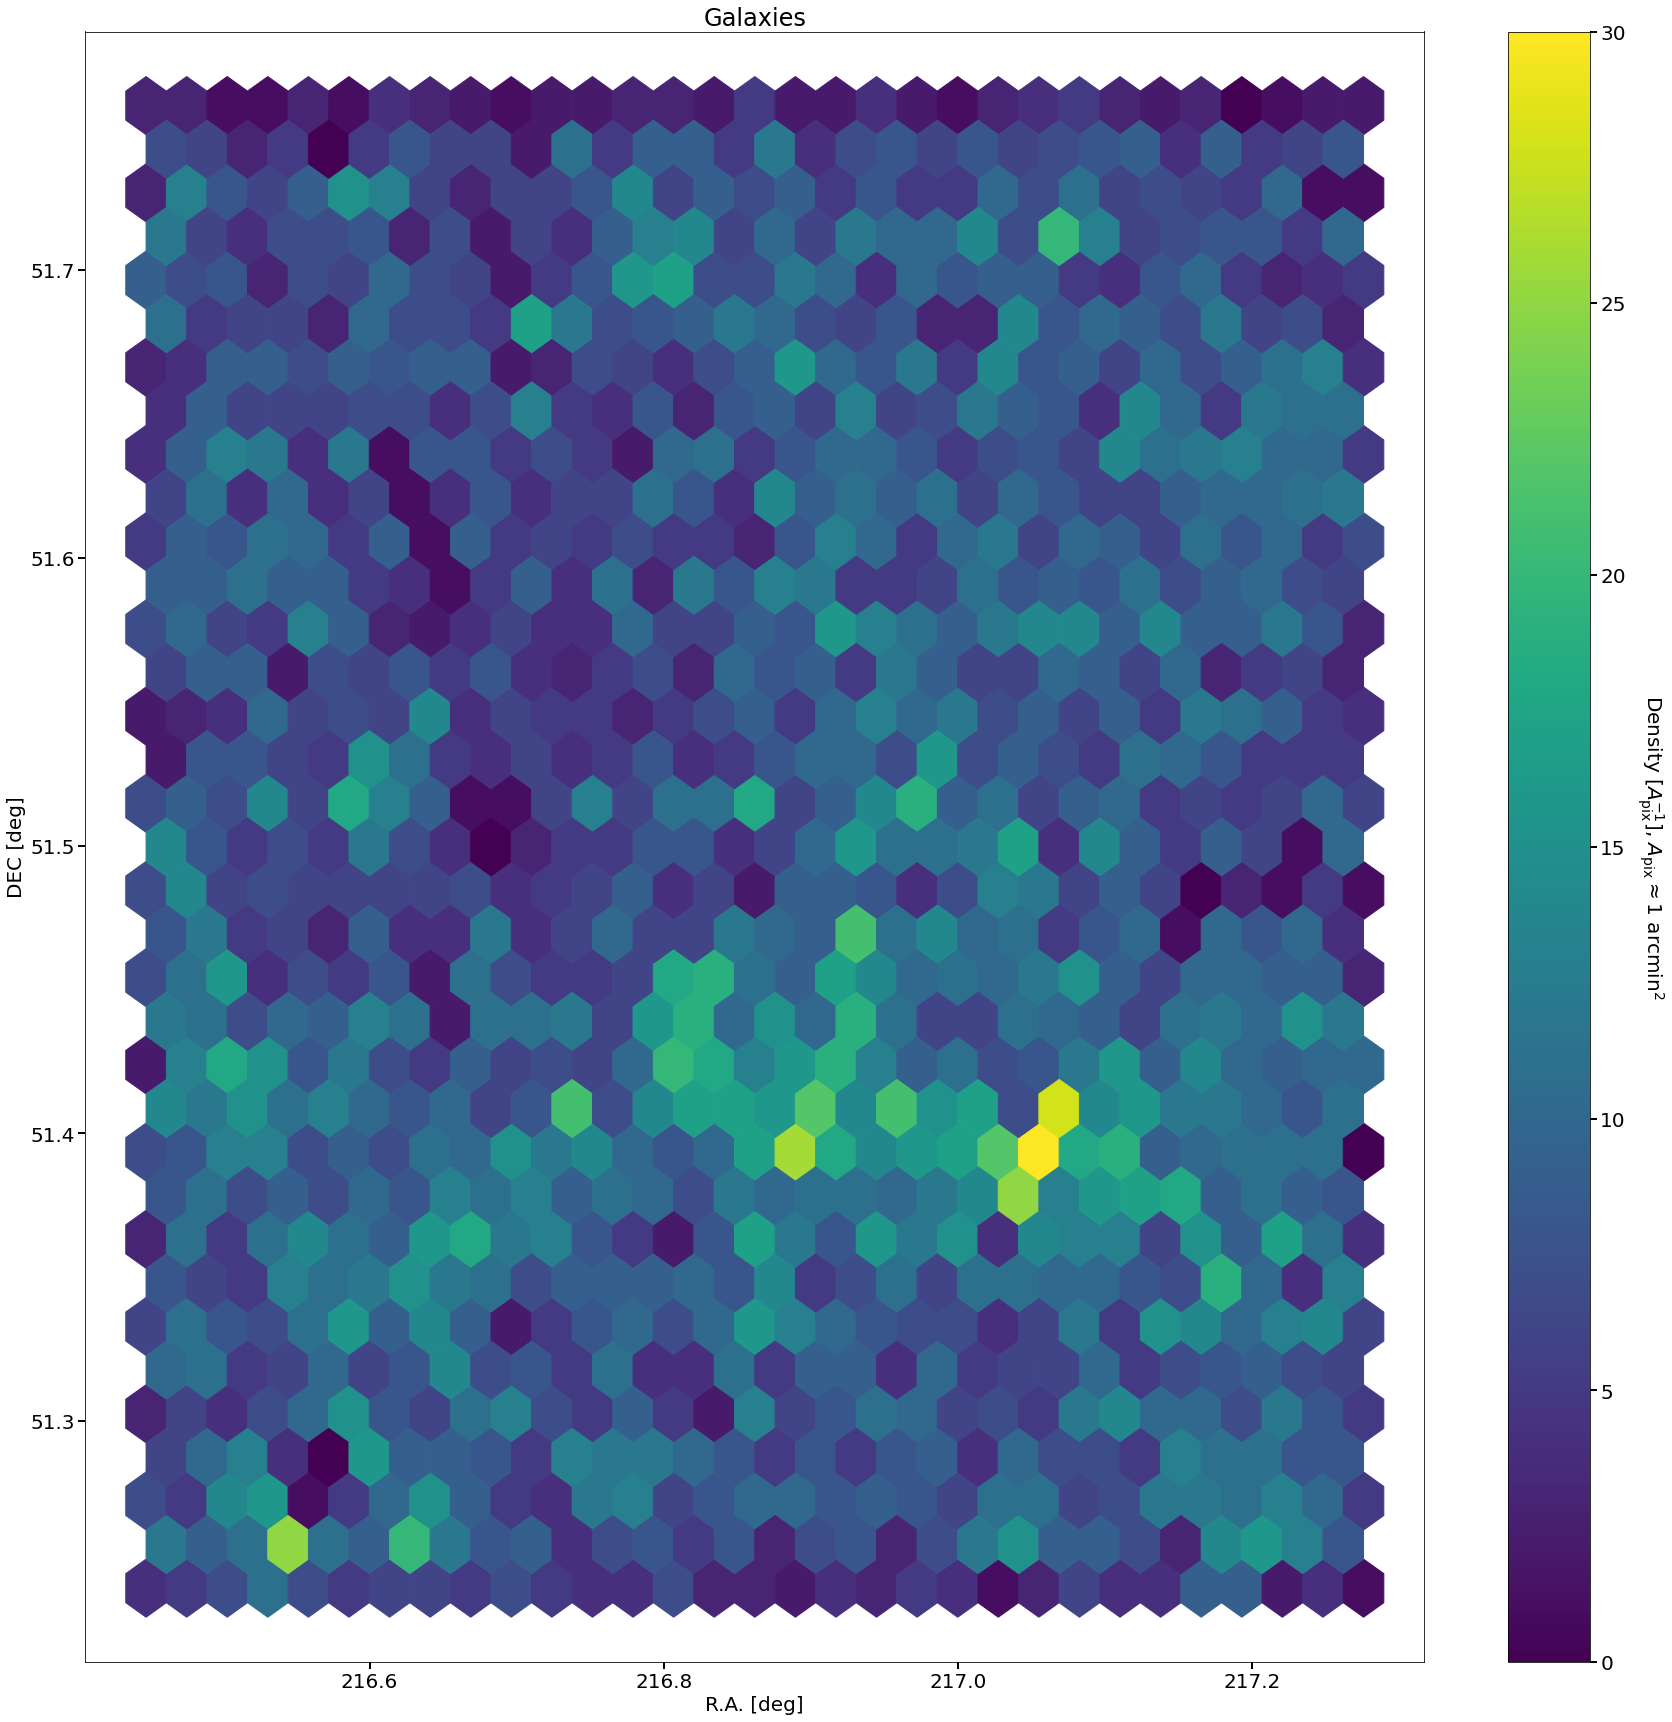

In [23]:
# Galaxies

ra = ra_ngmix
dec = dec_ngmix

Apix = 1 # [arcmin^2]
title = 'Galaxies'
out_name = 'galaxy_number_count_ngmix.png'

cbar_label = '{}, $A_{{\\rm pix}} \\approx {:.1g}$ arcmin$^2$'.format(cbar_label_base, Apix)
out_path = '{}/{}'.format(plot_dir, out_name)
n_grid = int(np.sqrt(area_amin2) / Apix)
if verbose:
    print('Number of pixels = {}'.format(n_grid))
plot_spatial_density(ra, dec, title, x_label, y_label, cbar_label, out_path, n_grid=n_grid, verbose=verbose)

Number of pixels = 30


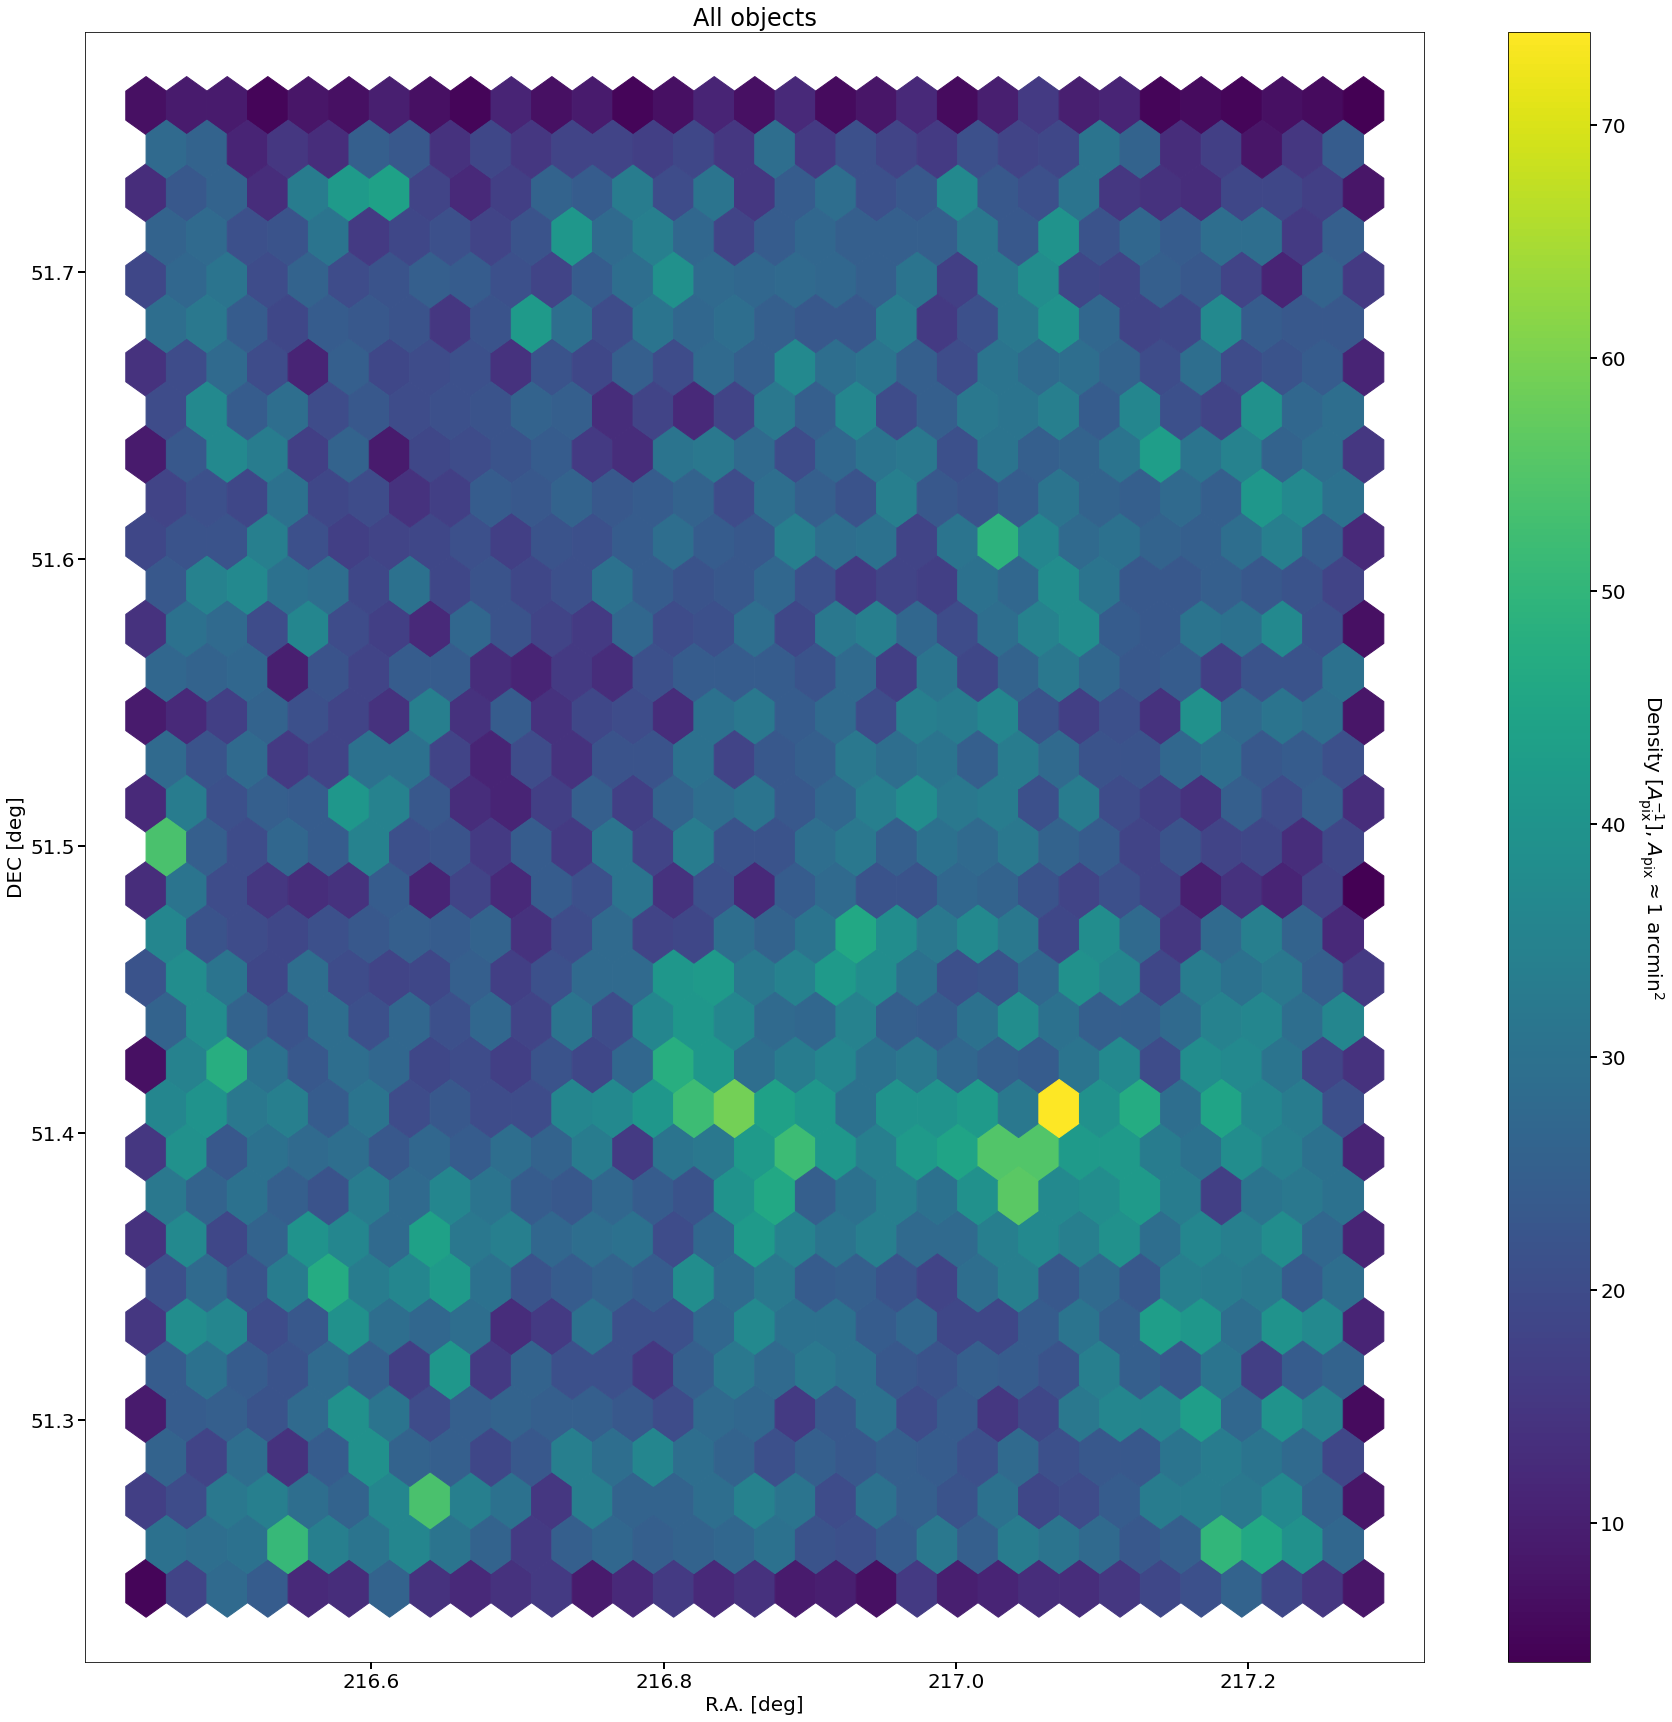

In [24]:
# All objects

ra = dd['XWIN_WORLD']
dec = dd['YWIN_WORLD']

Apix = 1 # [arcmin^2]
title = 'All objects'
out_name = 'object_number_count_ngmix.png'

cbar_label = '{}, $A_{{\\rm pix}} \\approx {:.1g}$ arcmin$^2$'.format(cbar_label_base, Apix)
out_path = '{}/{}'.format(plot_dir, out_name)
n_grid = int(np.sqrt(area_amin2) / Apix)
if verbose:
    print('Number of pixels = {}'.format(n_grid))
plot_spatial_density(ra, dec, title, x_label, y_label, cbar_label, out_path, n_grid=n_grid, verbose=verbose)

#### Plot galaxy signal-to-noise distribution
Plot both ngmix and galsim selection

ngmix:


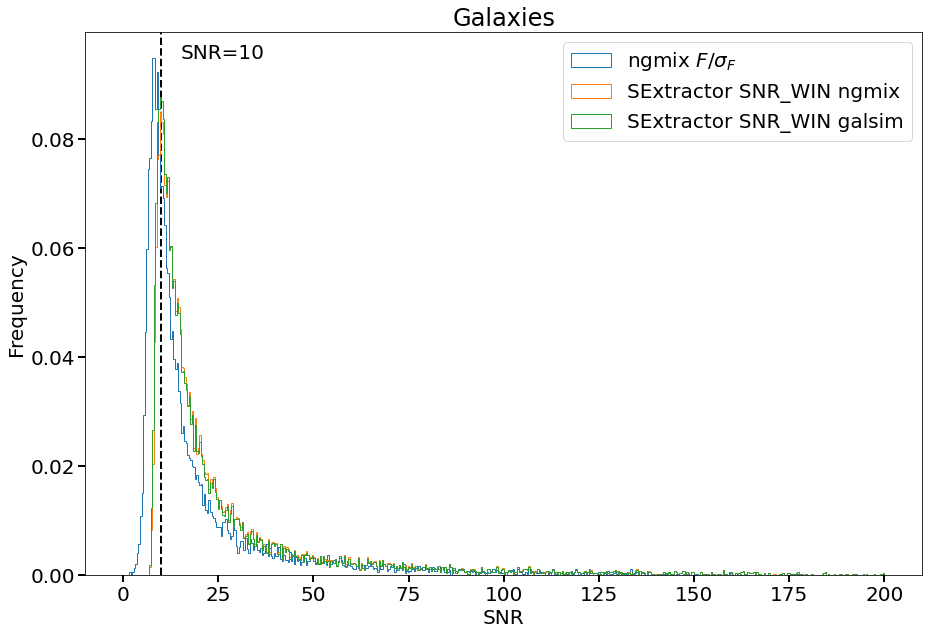

In [54]:
print_stats('ngmix:', stats_file, verbose=verbose)

# Do not apply `mask_ns`, so use all galaxies
ys = [dd['NGMIX_FLUX_NOSHEAR'][m_gal_ngmix]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_ngmix],
      dd['SNR_WIN'][m_gal_ngmix],
      dd['SNR_WIN'][m_gal_galsim],
     ]
labels = ['ngmix $F/\\sigma_F$', 'SExtractor ngmix selection', 'SExtractor SNR galsim selection']

x_label = 'SNR'
y_label = 'Frequency'
title = 'Galaxies'
density = True
x_max = 200
n_bin = 500
out_name = 'hist_SNR_ngmix.pdf'
out_path = os.path.join(plot_dir, out_name)

plt.figure(figsize=(15,10))

for y, label in zip(ys, labels):
    plt.hist(y, n_bin, range=(0, x_max), histtype='step', density=True, label=label)
 
ylim = plt.ylim()

plt.vlines(x=10, ymax=ylim[1], ymin=0, linestyles='--', colors='k')
plt.text(10*1.5, ylim[1]*0.95, 'SNR=10')
plt.legend()

plt.ylim(ylim)

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.savefig(out_path)

In [ ]:
gal_metacal_galsim = metacal(dd, m_gal_galsim, prefix='GALSIM')

In [ ]:
g_galsim = np.array([gal_metacal_galsim.ns['g1'][gal_metacal_galsim.mask_dict['ns']], gal_metacal_galsim.ns['g2'][gal_metacal_galsim.mask_dict['ns']]])
g_corr_galsim = np.linalg.inv(gal_metacal_galsim.R).dot(g_galsim)
w_galsim = gal_metacal_galsim.ns['w'][gal_metacal_galsim.mask_dict['ns']]
ra_galsim = dd['XWIN_WORLD'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
dec_galsim = dd['YWIN_WORLD'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
mag_galsim = dd['MAG_AUTO'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]
#snr_galsim = dd['NGMIX_FLUX_NOSHEAR'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]/dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal_galsim][gal_metacal_galsim.mask_dict['ns']]

In [ ]:
n_gal_galsim = len(g_galsim[0])
n_tiles = 214 #len(list(set(dd['TILE_ID'])))
area_tiles = 0.25
area_deg = n_tiles*area_tiles
tot_area = area_deg*3600
d_gal_galsim = n_gal_galsim / tot_area
print("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2".format(n_gal_galsim, d_gal_galsim))
stats_file.write("Final number of galaxies : {}\nGalaxy density : {:.2f} gal/arcmin2\n".format(n_gal_galsim, d_gal_galsim))

In [ ]:
plt.figure(figsize=(30, 30))
plt.hexbin(ra_galsim, dec_galsim, gridsize=1000)
cbar = plt.colorbar()
cbar.set_label('Number count', rotation=270)
plt.title("Galaxy number count")
plt.xlabel("Ra (Deg)")
plt.ylabel("Dec (Deg)")
plt.savefig(plot_dir + 'galaxy_number_count_galsim.png')

In [ ]:
run_metacal = True